<a href="https://colab.research.google.com/github/iceik973-dotcom/ML1/blob/main/%D0%9B%D0%A0_2_2_%D0%93%D1%80%D0%B8%D0%B3%D0%BE%D1%80%D0%B8%D1%88%D0%B5%D0%BD_3_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### 1. Завантаження датасету

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")

print("Path to dataset files:", path)

100%|██████████| 22.0k/22.0k [00:00<00:00, 28.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mahmoudshogaa/titanic-dataset/versions/1


In [3]:
df = pd.read_csv(os.path.join(path, "titanic.csv"))

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


2. Визначити розмір датасета.
3. Визначити тип даних.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Висновок:** Датасет містить 891 рядок та 12 колонок. Ознаки мають числові (`int64`, `float64`) та текстові/об'єктні (`object`) типи даних. У стовпчиках `Age`, `Cabin` та `Embarked` наявні пропущені значення.

In [5]:
df.duplicated().sum()

np.int64(0)

**Висновок:** Повних дублікатів рядків у датасеті немає (знайдено 0).

4. Визначити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Висновок:** Виявлено пропуски: `Age` — 177, `Cabin` — 687, `Embarked` — 2. Стовпчик `Cabin` містить забагато пропусків, тому його доцільно вилучити, а вік — заповнити медіанним значенням.

Вирішили пропущені значення замінити на медіану (а можна на середнє)

In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median(skipna=True))

df.drop(['Cabin'], axis=1, inplace=True)
df.drop(['Embarked'], axis=1, inplace=True)

5. Ще раз перевірити наявність пропущених значень.

In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


**Висновок:** Усі пропущені значення успішно оброблені — в усіх колонках залишилось по 0 пропусків.

6. Сформувати датасет з обраними стовпцями: ['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

In [9]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


7. Замінити бінарні ознаки (Стать) на 0 і 1 (але перевірте унікальні значення даного стовпчика). Буває, що є середня стать)

In [10]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


**Висновок:** У стовпчику статі представлені лише два класи: чоловіки (`male` — 577) та жінки (`female` — 314). Інших або аномальних значень немає.

In [11]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print(f'Data types of the dataset:\n{df.dtypes}')

Data types of the dataset:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
Fare        float64
dtype: object


/tmp/ipykernel_7540/275882515.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})


**Висновок:** Стать перекодовано у числовий формат (чоловіки = 0, жінки = 1). Усі колонки набору мають числовий тип.

8. Вивести описову статистику датасету describe()

In [12]:
df.describe()

,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,32.204208
std,0.486592,0.836071,0.477990,13.019697,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,14.454200
75%,1.000000,3.000000,1.000000,35.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


**Висновок:** Середній рівень виживання становить ~38.4%. Середній вік пасажирів складає близько 29.4 років, а середня вартість квитка — 32.20 при максимальній ціні 512.33.

9. Ще раз перевірити кількість пропущених даних (впевнитись, що їх немає).

In [13]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0


10. Вивести 5 перших рядків датасету.

In [14]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


11. Вивести 5 останніх рядків датасету.

In [15]:
df.tail()

,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.0,13.00
887,1,1,1,19.0,30.00
888,0,3,1,28.0,23.45
889,1,1,0,26.0,30.00
890,0,3,0,32.0,7.75


12. Аналіз виживання залежно від статі: Обчисліть відсоток виживання для кожної статі. Чи була різниця у виживанні між чоловіками та жінками?

In [16]:
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100

print(f'Share of survived males: {survival_by_sex[0]:.2f}%')
print(f'Share of survived females: {survival_by_sex[1]:.2f}%')

Share of survived males: 18.89%
Share of survived females: 74.20%


In [17]:
print(f'Correlation between sex and survival: {df["Sex"].corr(df["Survived"])}')

Correlation between sex and survival: 0.5433513806577555


**Відповідь:** Існує суттєва різниця у виживанні: серед жінок вижило 74.20%, тоді як серед чоловіків — лише 18.89%[cite: 1]. Кореляція між статтю та виживанням становить 0.54, що свідчить про помітний прямий зв'язок[cite: 1].

13. Обчисліть відсоток виживання для кожного класу (Pclass). Який клас мав найвищий рівень виживання (дати відповідь)?

In [18]:
class1_surv_rate = df[(df['Pclass'] == 1) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 1].shape[0]
class2_surv_rate = df[(df['Pclass'] == 2) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 2].shape[0]
class3_surv_rate = df[(df['Pclass'] == 3) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 3].shape[0]

print(f'Share of survived class 1 passengers {class1_surv_rate * 100:.2f}%')
print(f'Share of survived class 2 passengers {class2_surv_rate * 100:.2f}%')
print(f'Share of survived class 3 passengers {class3_surv_rate * 100:.2f}%')

Share of survived class 1 passengers 62.96%
Share of survived class 2 passengers 47.28%
Share of survived class 3 passengers 24.24%


**Відповідь:** Найвищий рівень виживання мав перший клас — 62.96%[cite: 1]. У другому класі частка вижилих склала 47.28%, а в третьому — найменше, 24.24%[cite: 1].

14. Визначте середній вік тих, хто вижив, і тих, хто не вижив. Чи впливає вік на виживання (дати відповідь)?

In [19]:
survived_mean_age = df[df['Survived'] == 1]['Age'].mean()
not_survived_mean_age = df[df['Survived'] == 0]['Age'].mean()

print(f'Mean age of survived passengers: {survived_mean_age:.2f}')
print(f'Mean age of not survived passengers: {not_survived_mean_age:.2f}')

Mean age of survived passengers: 28.29
Mean age of not survived passengers: 30.03


**Відповідь:** Середній вік тих, хто вижив — 28.29 років, а тих, хто загинув — 30.03 років[cite: 1]. Прямий вплив самого середнього віку незначний, проте молодші пасажири мали трохи вищі шанси на порятунок.

15. Розподіліть пасажирів на групи за рівнями тарифів (Fare) і обчисліть рівень виживання для кожної групи. Як тариф впливав на шанси виживання (дати відповідь)?

In [20]:
survived_mean_age = df[df['Survived'] == 1]['Age'].mean()
not_survived_mean_age = df[df['Survived'] == 0]['Age'].mean()

print(f'Mean age of survived passengers: {survived_mean_age:.2f}')
print(f'Mean age of not survived passengers: {not_survived_mean_age:.2f}')

Mean age of survived passengers: 28.29
Mean age of not survived passengers: 30.03


16. Аналіз класу та тарифу: Визначте середній тариф (Fare) для кожного класу (Pclass). Чи існує значна різниця у тарифах між класами (дати відповідь)?

In [21]:
df['Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)

for i in range(6):
    surv_rate = df[(df['Fare_Category'] == i) & (df['Survived'] == 1)].shape[0] / df[df['Fare_Category'] == i].shape[0]
    print(f'Share of survived passengers in bucket {i}: {surv_rate * 100:.2f}%')

Share of survived passengers in bucket 0: 20.51%
Share of survived passengers in bucket 1: 19.08%
Share of survived passengers in bucket 2: 36.69%
Share of survived passengers in bucket 3: 43.62%
Share of survived passengers in bucket 4: 41.78%
Share of survived passengers in bucket 5: 69.80%


/tmp/ipykernel_7540/1421978565.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)


**Відповідь:** Чим дорожчий квиток, тим вищі шанси на виживання: для групи з найдешевшими тарифами (група 0) частка вижилих становить 20.51%, а для найдорожчих квитків (група 5) — 69.80%[cite: 1]. Ціни на квитки першого класу значно дорожчі за другий та третій класи. Коли різниця між третім та другим у 2 рази, то між другим та першим майже 4 рази[cite: 2].

17. Як пов'язано середній вік пасажирів з виживанням? Відповідь дати аналітично чи графічно

<Axes: xlabel='Age', ylabel='Count'>

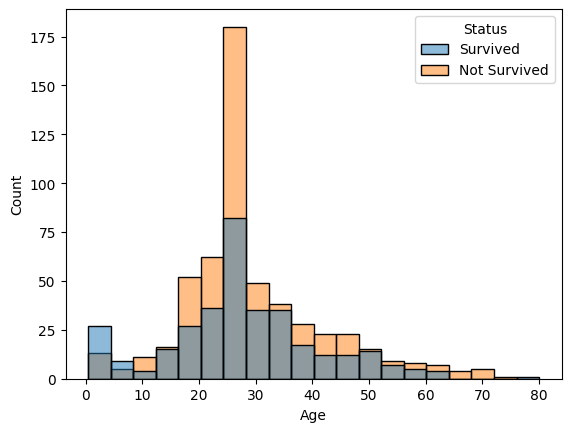

In [22]:
df_survived = df[df['Survived'] == 1][['Age']]
df_survived['Status'] = 'Survived'

df_not_survived = df[df['Survived'] == 0][['Age']]
df_not_survived['Status'] = 'Not Survived'

df_combined = pd.concat([df_survived, df_not_survived])

sns.histplot(data=df_combined, x='Age', hue='Status', bins=20)

**Висновок:** Гістограма показує найвищу частку порятунку серед дітей раннього віку (до 5–10 років). Для пасажирів працездатного віку (20–40 років) кількість загиблих суттєво переважає.

In [23]:
for i in range(1, 4):
    for j in range(2):
        surv_rate = df[(df['Pclass'] == i) & (df['Sex'] == j) & (df['Survived'] == 1)].shape[0] / df[(df['Pclass'] == i) & (df['Sex'] == j)].shape[0]
        print(f'Share of survived {"male  " if j == 0 else "female"} passengers in class {i}: {surv_rate * 100:.2f}%')

Share of survived male   passengers in class 1: 36.89%
Share of survived female passengers in class 1: 96.81%
Share of survived male   passengers in class 2: 15.74%
Share of survived female passengers in class 2: 92.11%
Share of survived male   passengers in class 3: 13.54%
Share of survived female passengers in class 3: 50.00%


**Висновок:** Найбільш захищеними були жінки з 1-го (96.81%) та 2-го (92.11%) класів[cite: 1]. Найменший рівень виживання зафіксовано серед чоловіків 2-го (15.74%) та 3-го (13.54%) класів[cite: 1].

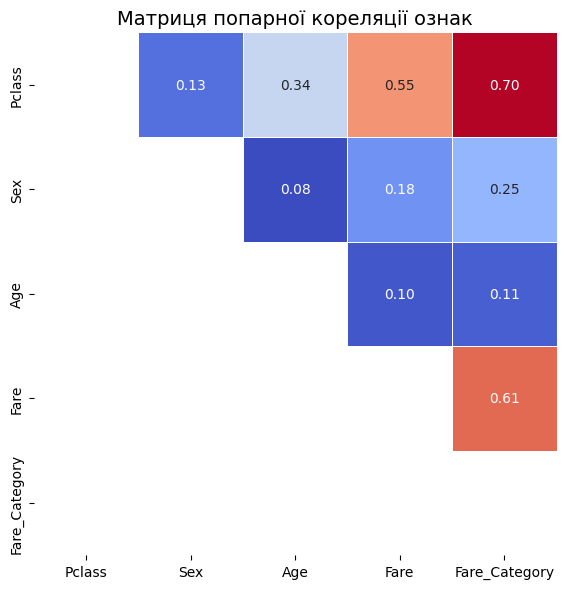

In [24]:
mtx = df.drop('Survived', axis=1).corr(numeric_only=True).abs()

fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    mtx,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    mask=np.tril(np.ones_like(mtx, dtype=bool)),
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()

**Висновок:** Найсильніший попарний лінійний зв'язок спостерігається між класом квитка (`Pclass`) та вартістю (`Fare`) — абсолютне значення кореляції 0.55. Зв'язки між іншими незалежними ознаками є слабкими.

**Загальний висновок**

Проведений розвідувальний аналіз даних (EDA) пасажирів «Титаніка» дозволяє виділити ключові закономірності, що безпосередньо впливали на рівень виживання:

* **Стать як вирішальний фактор:** Жінки мали колосальну перевагу в порятунку — вижило 74.20% жінок проти лише 18.89% чоловіків. Кореляція між статтю та виживанням склала 0.54, підтверджуючи пріоритет посадки у шлюпки за принципом «жінки та діти першими».


* **Соціально-економічний статус (клас і тариф):** Рівень виживання прямо пропорційний достатку та класу каюти. Найвищий відсоток виживання зафіксовано у 1-му класі (62.96%), тоді як у 3-му класі врятувалося лише 24.24%. Аналогічно, пасажири з найвищими тарифами виживали значно частіше (до 69.80%), ніж ті, хто подорожував найдешевшими категоріями (близько 20.5%).


* **Віковий розподіл:** Хоча середній вік тих, хто вижив (28.29 років), і тих, хто загинув (30.03 років), суттєво не відрізняється, розподіл на гістограмі демонструє помітно вищий шанс на порятунок у маленьких дітей (до 5–10 років).


* **Синергетичний ефект:** Найбільш захищеною групою виявилися жінки 1-го та 2-го класів (понад 92–96% вижилих), а найуразливішою — чоловіки 2-го та 3-го класів, де рівень виживання коливався в межах 13–15%.



Таким чином, головними факторами виживання на судні були стать пасажира та його соціально-економічне становище (клас каюти й вартість квитка).